In [ ]:
import pandas as pd
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBClassifier
from tabpfn_client import TabPFNClassifier, set_access_token
from RandomRotationEnsemble import RandomRotationEnsemble
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import (confusion_matrix, roc_curve, auc, accuracy_score, f1_score,
                             precision_recall_curve, ConfusionMatrixDisplay)
import matplotlib.gridspec as gridspec

from dotenv import dotenv_values
import warnings
from sklearn.exceptions import ConvergenceWarning


warnings.filterwarnings("ignore", category=ConvergenceWarning)


config = dotenv_values(".env")
token = config['TABPFN_TOKEN']
set_access_token(token)


In [4]:
train_processed=pd.read_csv("datasets/train_processed.csv")
val_processed=pd.read_csv("datasets/val_processed.csv")
test_processed=pd.read_csv("datasets/X_test_processed.csv")

train_augmented=pd.read_csv("datasets/train_augmented.csv")
val_augmented=pd.read_csv("datasets/X_val_augmented.csv")
test_augmented=pd.read_csv("datasets/X_test_processed.csv")


In [5]:
X_train_preprocessed=train_processed.drop("Transported", axis=1)
X_val_preprocessed=val_processed.drop("Transported", axis=1)
y_train_preprocessed=train_processed.Transported
y_val_preprocessed=val_processed.Transported


X_train_augmented=train_augmented.drop("Transported", axis=1)
X_val_augmented=val_augmented.drop("Transported", axis=1)
y_train_augmented=train_augmented.Transported
y_val_augmented=val_augmented.Transported

X_test=test_processed

In [6]:
obj_cols = val_augmented.select_dtypes(include='object').columns
for col in obj_cols:
    val_augmented[col] = val_augmented[col].replace({'True': 1, 'False': 0}).astype(float).astype(int)

### making a baseline model to compare to more complex models

In [7]:

baseline_model=DummyClassifier(random_state=23)
baseline_model.fit(X_train_preprocessed,y_train_preprocessed)
predict_preprocessed=baseline_model.predict(X_val_preprocessed)
accuracy_baseline_preprocessed=accuracy_score(y_val_preprocessed,predict_preprocessed)
print(accuracy_baseline_preprocessed)


baseline_model_aug=DummyClassifier(random_state=23)
baseline_model_aug.fit(X_train_augmented,y_train_augmented)
predict=baseline_model_aug.predict(X_val_augmented)
accuracy_aug=accuracy_score(y_val_augmented, predict)
print(accuracy_aug)

0.4901462174189447
0.496262219666475


In [8]:
split_index_preprocessed = np.concatenate([
    np.full(len(X_train_preprocessed), -1),  
    np.zeros(len(X_val_preprocessed))        
])
predefined_split_preprocessed=PredefinedSplit(split_index_preprocessed)
X_combo_preprocessed=pd.concat([X_train_preprocessed,X_val_preprocessed])
y_combo_preprocessed=pd.concat([y_train_preprocessed,y_val_preprocessed])


split_index_augmented = np.concatenate([
    np.full(len(X_train_augmented), -1),  
    np.zeros(len(X_val_augmented))        
])
predefined_split_augmented=PredefinedSplit(split_index_augmented)
X_combo_augmented=pd.concat([X_train_augmented,X_val_augmented])
y_combo_augmented=pd.concat([y_train_augmented,y_val_augmented])


### finding the best hyperparameters via GridSearch and training the models

In [9]:
models={"preprocessed": {}, "augmented":{}}

models["preprocessed"]={"baselinemodel":[baseline_model,accuracy_baseline_preprocessed]}
models["augmented"]={"baselinemodel": [baseline_model_aug,accuracy_aug]}

def best_hyperparameters(model,model_name,params, X_combo,y_combo, split,d_type):
    best_m=GridSearchCV(model(random_state=42),param_grid=params,cv=split,scoring="accuracy",n_jobs=-1,refit=True)
    best_m.fit(X_combo,y_combo)
    models[d_type][model_name]=[best_m.best_estimator_, best_m.best_score_]
    print(d_type)
    print(f"model : {model_name}")
    print(f"Beste parametre: {best_m.best_params_}")
    print(f"Beste val-score : {best_m.best_score_:.4f}")   
    print()
    
params={}
params_RandomForrest= {'n_estimators': [100, 200, 300,400],
                       'max_depth': [None, 10, 20,30],
                       'min_samples_leaf': [ 2, 4,6],
                       'bootstrap': [True, False] ,

}  
params["random_forest"]=params_RandomForrest

params_xg_boost= {
    'n_estimators': [100, 200, 300,400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
params["xg_boost"]=params_xg_boost

params_logistic_regression=[
   { "penalty":['l1', 'l2'],
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ['saga'],
    "max_iter": [5000] },
    {
        "penalty": ['elasticnet'],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ['saga'],
        "max_iter": [5000],
        "l1_ratio": [0.2, 0.5, 0.8]
    }
]
params["logistic_regression"]=params_logistic_regression

params_decision_tree = {
    'max_depth': [3, 5, 10, 20, None,50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
params["decision_tree"]=params_decision_tree


models_to_train=[(RandomForestClassifier, "random_forest"),(XGBClassifier,"xg_boost" ) ,(LogisticRegression,"logistic_regression" ), (tree.DecisionTreeClassifier,"decision_tree")]
for model,name in models_to_train:
    current_param=params[name]
    best_hyperparameters(model,name,current_param,
                        X_combo_preprocessed, y_combo_preprocessed,
                        predefined_split_preprocessed,"preprocessed")
    best_hyperparameters(model,name,current_param,
                        X_combo_augmented, y_combo_augmented,
                        predefined_split_augmented, "augmented")



preprocessed
model : random_forest
Beste parametre: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 6, 'n_estimators': 300}
Beste val-score : 0.8017

augmented
model : random_forest
Beste parametre: {'bootstrap': True, 'max_depth': 30, 'min_samples_leaf': 4, 'n_estimators': 200}
Beste val-score : 0.7959

preprocessed
model : xg_boost
Beste parametre: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 1.0}
Beste val-score : 0.8074

augmented
model : xg_boost
Beste parametre: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
Beste val-score : 0.8005

preprocessed
model : logistic_regression
Beste parametre: {'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 5000, 'penalty': 'elasticnet', 'solver': 'saga'}
Beste val-score : 0.7864

augmented
model : logistic_regression
Beste parametre: {'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 5000, 'penalty': 'elasticnet', 'solver': 'saga'}
Beste val-score : 

### Training tabpfn

In [10]:
#reading and prepairing unaltered data for tabpfn training
raw_data=pd.read_csv("datasets/train.csv")
X_rawdata=raw_data.drop("Transported", axis=1)
label=raw_data.Transported
X_train_raw,X_val_raw,y_train_raw,y_val_raw=train_test_split(X_rawdata,label,test_size=0.2, random_state=42)
X_train_raw = X_train_raw.drop(['PassengerId', 'Name', 'Cabin'], axis=1)
X_val_raw = X_val_raw.drop(['PassengerId', 'Name', 'Cabin'], axis=1)


In [11]:
tab_pfn_processed = TabPFNClassifier(model_path="v2.5_default",random_state=42)
tab_pfn_processed.fit(X_train_preprocessed, y_train_preprocessed)
acc=accuracy_score(y_val_preprocessed, tab_pfn_processed.predict(X_val_preprocessed))
models["preprocessed"]["tab_pfn"]=[tab_pfn_processed,acc]

Processing: 100%|██████████| [00:01<00:00]


In [12]:
tab_pfn_augmented=TabPFNClassifier(model_path="v2.5_default",random_state=42)
tab_pfn_augmented.fit(X_train_augmented,y_train_augmented)
accuracy=accuracy_score(y_val_augmented,tab_pfn_augmented.predict(X_val_augmented))
models["augmented"]["tab_pfn"]=[tab_pfn_augmented,accuracy]

Processing: 100%|██████████| [00:02<00:00]


In [13]:
#training pfn on the dataset that have not been altered
tab_pfn_raw=TabPFNClassifier(model_path="v2.5_default",random_state=42)
tab_pfn_raw.fit(X_train_raw,y_train_raw)
acc=accuracy_score(y_val_raw, tab_pfn_raw.predict(X_val_raw))
models["preprocessed"]["tabpfn_raw"]=[tab_pfn_raw,acc]
models["augmented"]["tabpfn_raw"]=[tab_pfn_raw,acc]

Processing: 100%|██████████| [00:00<00:00]


### Training ensemble models with and without randomly rotated feature spaces

In [14]:
# Rotated
params_ensemble={}
params_rotated_rf = {
    'base_learner': ['rf'],
    'n_estimators': [10, 15, 20, 30],
    'use_rotation':[True],
    'max_depth':[None, 5, 10]
}
params_ensemble["rrrf"]=params_rotated_rf
params_rotated_extra_t = {
    'base_learner': ['extra'],
    'n_estimators': [10, 15, 20, 30],
    'use_rotation':[True],
    'max_depth':[None, 5, 10]
}
params_ensemble["rrex"]=params_rotated_extra_t
params_rotated_dt = {
    'base_learner': [None],
    'n_estimators': [10, 15, 20, 30],
    'use_rotation':[True],
    'max_depth':[None, 5, 10]
}
params_ensemble["rrdt"]=params_rotated_dt

# Unrotated
params_unrotated_rf = {
    'base_learner': ['rf'],
    'n_estimators': [10, 15, 20, 30],
    'use_rotation':[False],
    'max_depth':[None, 5, 10]
}
params_ensemble["urrrf"]=params_unrotated_rf
params_unrotated_extra_t = {
    'base_learner': ['extra'],
    'n_estimators': [10, 15, 20, 30],
    'use_rotation':[False],
    'max_depth':[None, 5, 10]
}
params_ensemble["urrex"]=params_unrotated_extra_t
params_unrotated_dt = {
    'base_learner': [None],
    'n_estimators': [10, 15, 20, 30],
    'use_rotation':[False],
    'max_depth':[None, 5, 10]
}
params_ensemble["urrdt"]=params_unrotated_dt

for model_name in params_ensemble.keys():
    best_hyperparameters(RandomRotationEnsemble,model_name,
                        params_ensemble[model_name],X_combo_preprocessed,
                        y_combo_preprocessed, predefined_split_preprocessed,
                        "preprocessed")
    best_hyperparameters(RandomRotationEnsemble,model_name,
                        params_ensemble[model_name],X_combo_augmented,
                        y_combo_augmented, predefined_split_augmented,
                        "augmented")


preprocessed
model : rrrf
Beste parametre: {'base_learner': 'rf', 'max_depth': 10, 'n_estimators': 15, 'use_rotation': True}
Beste val-score : 0.7978

augmented
model : rrrf
Beste parametre: {'base_learner': 'rf', 'max_depth': 10, 'n_estimators': 30, 'use_rotation': True}
Beste val-score : 0.7838

preprocessed
model : rrex
Beste parametre: {'base_learner': 'extra', 'max_depth': None, 'n_estimators': 30, 'use_rotation': True}
Beste val-score : 0.7819

augmented
model : rrex
Beste parametre: {'base_learner': 'extra', 'max_depth': None, 'n_estimators': 30, 'use_rotation': True}
Beste val-score : 0.7614

preprocessed
model : rrdt
Beste parametre: {'base_learner': None, 'max_depth': None, 'n_estimators': 30, 'use_rotation': True}
Beste val-score : 0.7851

augmented
model : rrdt
Beste parametre: {'base_learner': None, 'max_depth': 10, 'n_estimators': 20, 'use_rotation': True}
Beste val-score : 0.7941

preprocessed
model : urrrf
Beste parametre: {'base_learner': 'rf', 'max_depth': 10, 'n_esti

### Visualization of the validation scores of all the models

In [15]:
def visualize_result(d_type,color):
    names = list(models[d_type].keys())
    scores = [models[d_type][key][1] for key in models[d_type]]

    sorted_pairs = sorted(zip(scores, names))
    scores, names = zip(*sorted_pairs)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(names, scores, color=color, width=0.75)
    ax.bar_label(bars, fmt='%.3f',padding=-15, color='black', fontsize=9)


    ax.set_ylim(0.46, 0.84)
    ax.set_ylabel('Validation Accuracy scores')
    ax.set_title(f'model comparison - models trained on {d_type} data', fontsize=13)

    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

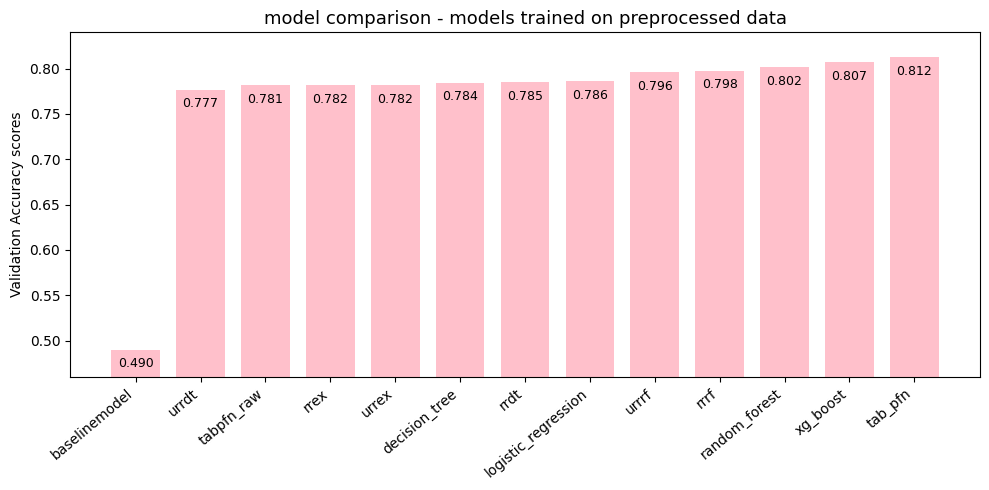

In [16]:
visualize_result("preprocessed","pink")

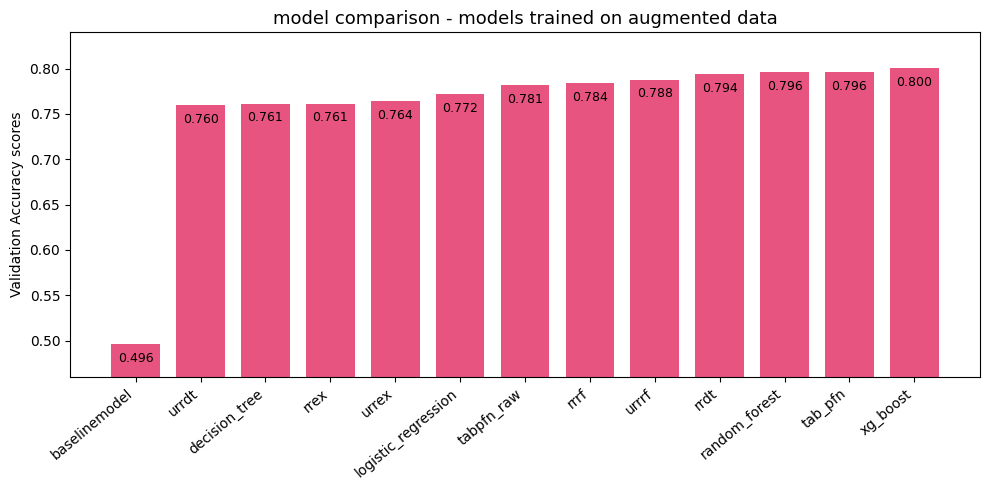

In [17]:
visualize_result("augmented","#E75480")

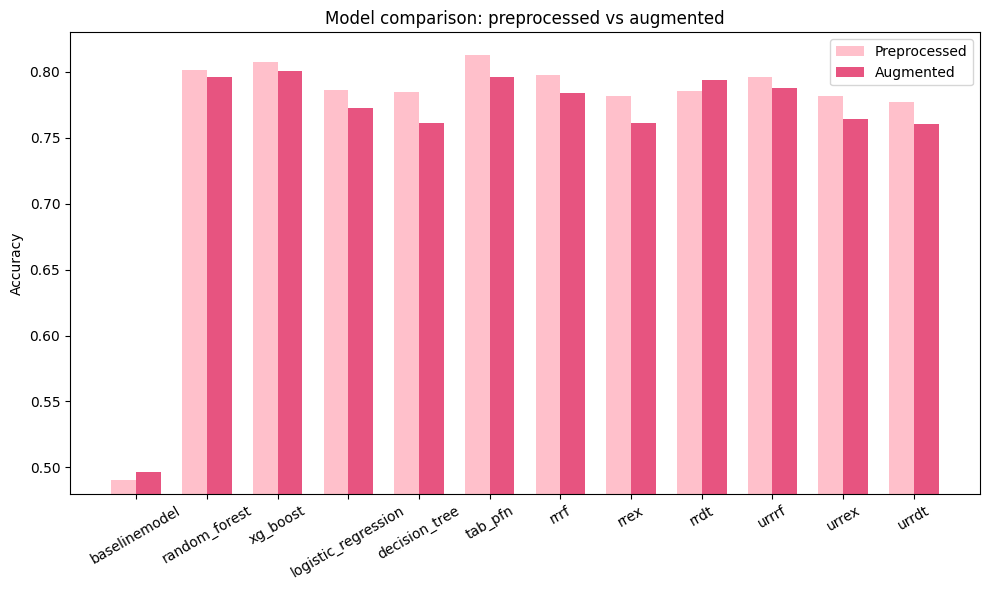

In [18]:
model_names = [name for name in models["preprocessed"].keys() if name != "tabpfn_raw"]
scores_preprocessed = [models["preprocessed"][name][1] for name in model_names ]
scores_augmented = [models["augmented"][name][1] for name in model_names ]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, scores_preprocessed, width, label="Preprocessed", color="pink")
ax.bar(x + width/2, scores_augmented, width, label="Augmented", color="#E75480")
ax.set_ylim(0.48, 0.83)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30)
ax.set_ylabel("Accuracy")
ax.set_title("Model comparison: preprocessed vs augmented")
ax.legend()
plt.tight_layout()
plt.show()

### Finding the best model and making submissions.csv

In [25]:

best_preprocessed = max([(name, model, score, "preprocessed") for name, (model, score) in models["preprocessed"].items()],key=lambda x: x[2])
best_augmented = max([(name, model, score, "augmented") for name, (model, score) in models["augmented"].items()],key=lambda x: x[2])
best_overall = max([best_preprocessed, best_augmented], key=lambda x: x[2]) 

name, best_model, best_score, data_type = best_overall
print(f"Best model: {name}, type: {data_type}, score: {best_score}")

predictions_test=best_model.predict(X_test)

#creating a submission csv file to send in to kaggle
test_id=pd.read_csv("datasets/ids_test.csv")
submission = pd.DataFrame({
    'PassengerId': test_id["PassengerId"],
    'Transported': predictions_test
})
submission['Transported'] = submission['Transported'].astype(bool)
submission.to_csv('datasets/submission.csv', index=False)

Best model: tab_pfn, type: preprocessed, score: 0.8124602670057216


Processing: 100%|██████████| [00:01<00:00]


We submitted submission.csv to https://www.kaggle.com/competitions/spaceship-titanic/data and received the final score 0.80453

In [20]:
def visualize_results(model, X_train, y_train, X_val, y_val, name):
    model.fit(X_train,y_train)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    cm = confusion_matrix(y_val, y_pred)
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    f1 = f1_score(y_val, y_pred)

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f"{name} Validation Set Performance", fontsize=15, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Transported", "Transported"])
    disp.plot(ax=ax1, colorbar=False, cmap="Blues")
    ax1.set_title("Confusion Matrix", fontweight="bold")
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.4f}")
    ax2.plot([0, 1], [0, 1], "k--", lw=1)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.set_title("ROC Curve", fontweight="bold")
    ax2.legend(loc="lower right")
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(recall, precision, color="orange", lw=2)
    ax3.set_xlabel("Recall")
    ax3.set_ylabel("Precision")
    ax3.set_title("Precision-Recall Curve", fontweight="bold")
    ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 0:2])
    ax4.hist(y_proba[y_val == 0], bins=40, alpha=0.6, color="blue", label="Not Transported")
    ax4.hist(y_proba[y_val == 1], bins=40, alpha=0.6, color="orange", label="Transported")
    ax4.set_xlabel("Predicted Probability")
    ax4.set_ylabel("Count")
    ax4.set_title("Prediction Probability Distribution", fontweight="bold")
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    ax5 = fig.add_subplot(gs[1, 2])
    from sklearn.calibration import calibration_curve
    prob_true, prob_pred = calibration_curve(y_val, y_proba, n_bins=10)
    ax5.plot(prob_pred, prob_true, "s-", color="green", label="TabPFN")
    ax5.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
    ax5.set_xlabel("Mean Predicted Probability")
    ax5.set_ylabel("Fraction of Positives")
    ax5.set_title("Calibration Curve", fontweight="bold")
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    plt.savefig(f"{name}.png", dpi=150, bbox_inches="tight")
    print(f1)
    plt.show()

augmented_name, best_augmented_model, best_augmented_score, _ = best_augmented
preprocessed_name, best_preprocessed_model, best_preprocessed_score, _ = best_preprocessed

0.7913409500901984


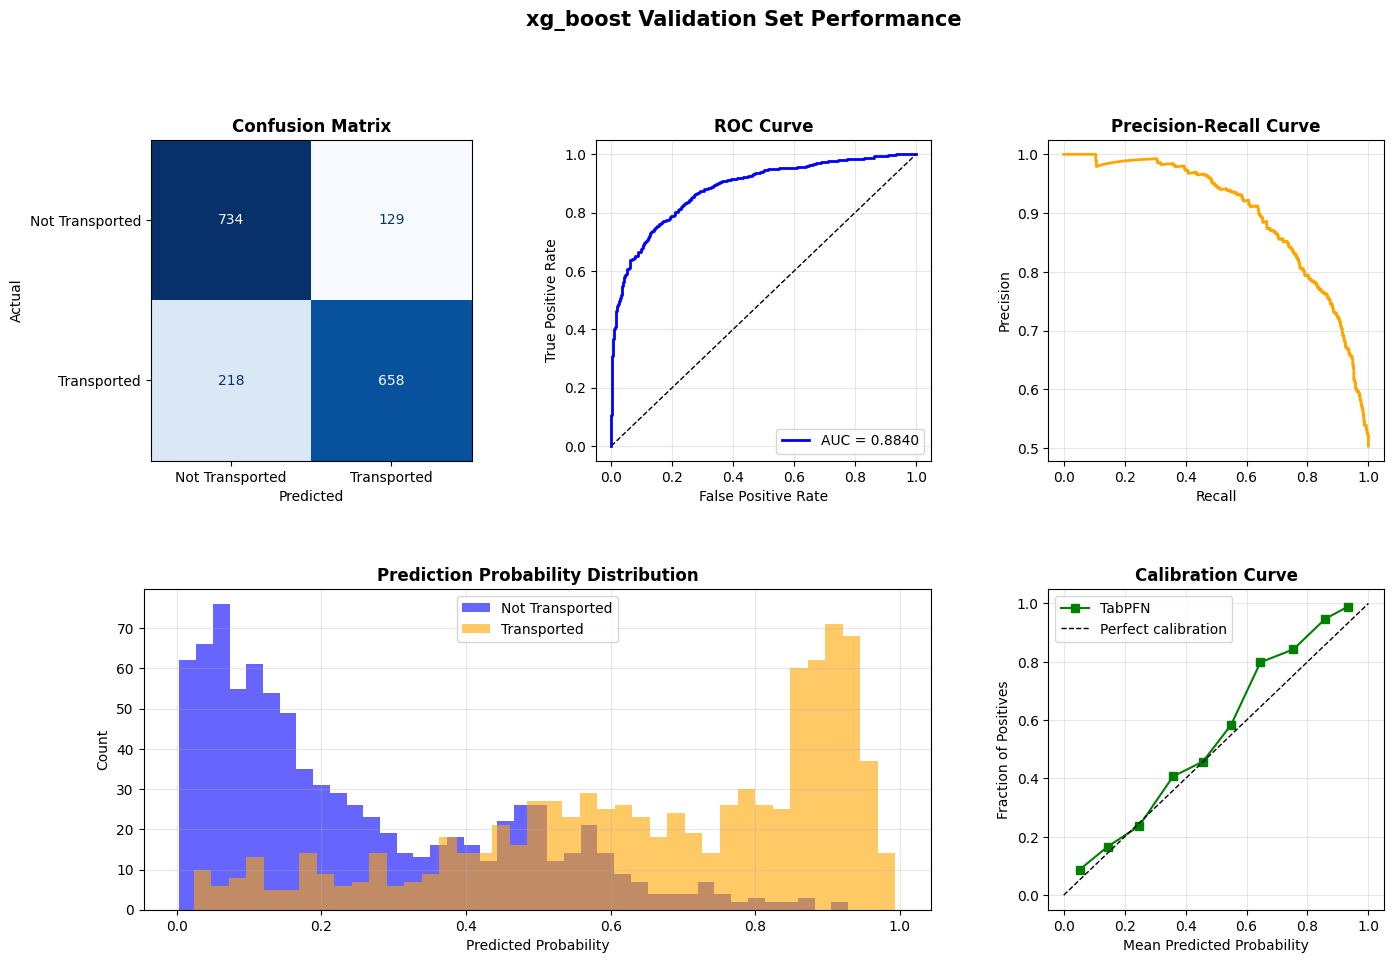

In [21]:
visualize_results(best_augmented_model, 
                  X_train_augmented, 
                  y_train_augmented, 
                  X_val_augmented, 
                  y_val_augmented,
                  augmented_name)

Processing: 100%|██████████| [00:01<00:00]
Processing:   0%|          | [00:01<00:00]


0.8150470219435737


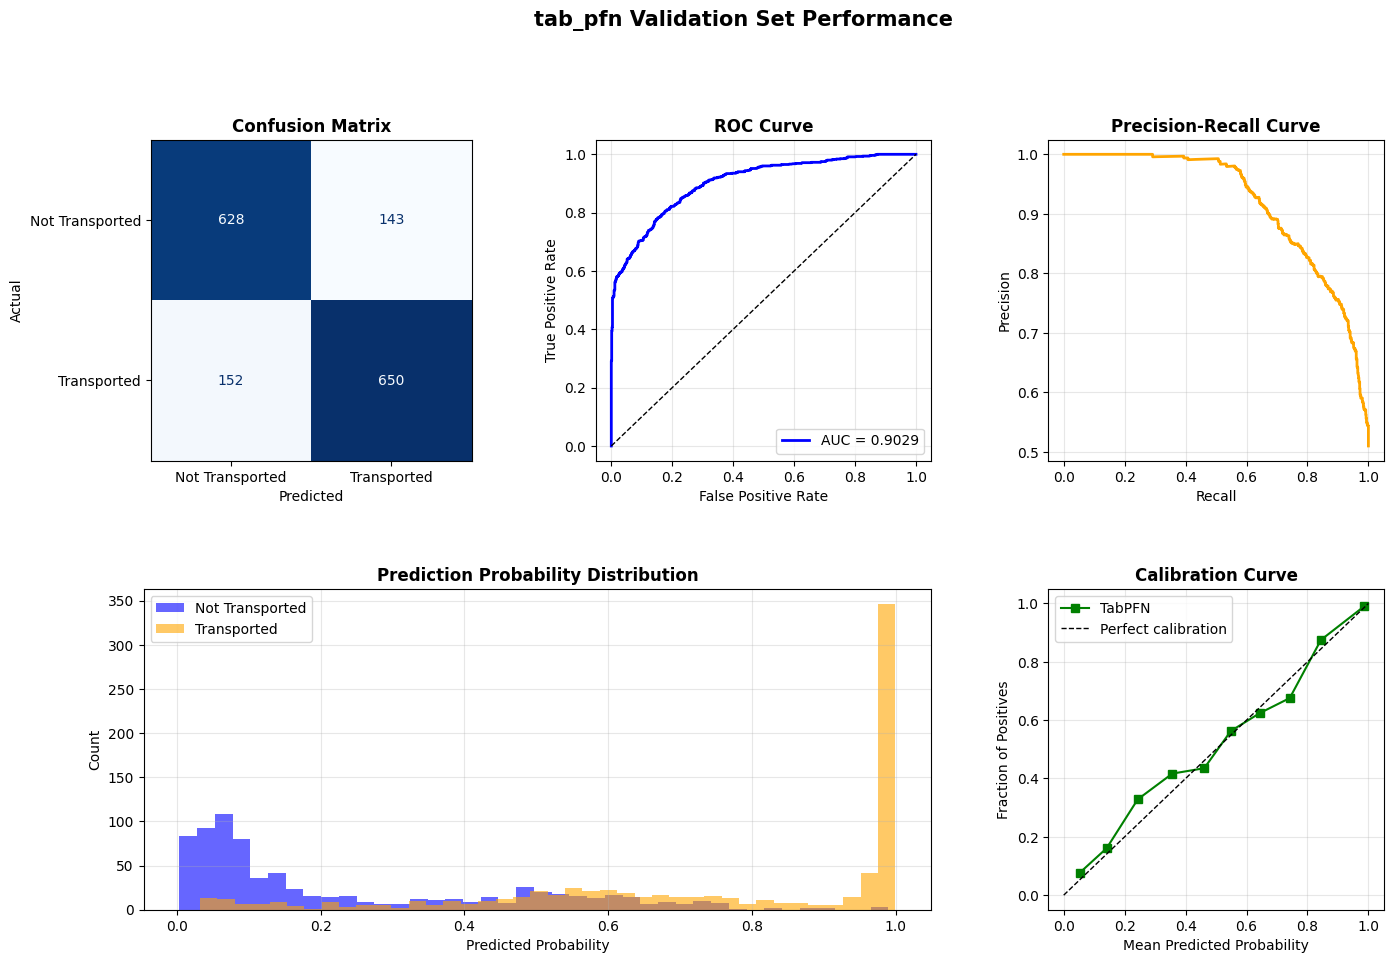

In [22]:
visualize_results(best_preprocessed_model, 
                  X_train_preprocessed, 
                  y_train_preprocessed, 
                  X_val_preprocessed, 
                  y_val_preprocessed,
                  preprocessed_name)

In [23]:
print("Best augmented score: ", best_augmented_score)
print("Best preprocessed score: ", best_preprocessed_score)

Best augmented score:  0.8004600345025877
Best preprocessed score:  0.8124602670057216
